# groupby · merge · pivot_table
### pivotando agregações e visualizando resultados com gráficos

**Objetivos da aula:** usar `groupby` com múltiplas colunas, `agg()` com várias funções, `merge` para cruzar tabelas, `pivot_table` para relatórios cruzados e plotar gráficos com `matplotlib`.


## Bloco 0 — Setup
Carregue a mesma base usada na semana passada e prepare o notebook para todos os exercícios desta aula.


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# URL da planilha que usamos nesta aula
URL = (
    "https://raw.githubusercontent.com/"
    "cfneves/turma-visualizacao-de-dados/"
    "master/alunos/felipe_vampre/semana_04/base_rh.xlsx"
)

# Lê o arquivo Excel diretamente da internet
df = pd.read_excel(URL)

# Converte a coluna de data de admissão para o tipo datetime
df["Data_Admissao"] = pd.to_datetime(
    df["Data_Admissao"],
    format="%d/%m/%Y",
    errors="coerce"
)

# Mostra quantas linhas e colunas temos e os tipos de cada coluna
print(f"Dataset: {df.shape[0]} linhas x {df.shape[1]} colunas")
print(df.dtypes)


Dataset: 1000 linhas x 10 colunas
ID_Funcionario             int64
Nome                         str
Departamento                 str
Cargo                        str
Salario                  float64
Data_Admissao     datetime64[us]
Genero                       str
Idade                      int64
Estado_Civil                 str
Status                       str
dtype: object


## Bloco 1 — groupby: agrupando e resumindo dados
groupby funciona como o `GROUP BY` do SQL: você escolhe colunas para agrupar, escolhe o valor a calcular e escolhe a função de agregação.


### Exemplo 01 — resumo salarial por departamento
Use `groupby` em uma coluna e `agg()` com múltiplas funções para obter uma tabela resumida.


In [8]:
# Agrupa o DataFrame por departamento e calcula várias estatísticas de salário
resumo = (
    df.groupby("Departamento")["Salario"]
    .agg(
        quantidade="count",  # conta quantos funcionários existem em cada departamento
        media="mean",       # calcula o salário médio
        mediana="median",   # calcula o salário mediano
        minimo="min",       # encontra o salário mais baixo
        maximo="max"        # encontra o salário mais alto
    )
    .round(2)
    .sort_values("media", ascending=False)  # ordena do maior para o menor salário médio
    .reset_index()  # transforma o índice gerado pelo groupby em colunas normais
)

print(resumo.to_string(index=False))


Departamento  quantidade   media  mediana  minimo   maximo
    Produção         182 8968.73  9228.67 2001.65 14951.53
   Logística         156 8881.66  8837.74 2000.71 14889.69
          RH         166 8791.58  8790.54 2224.18 14942.39
  Financeiro         189 8333.12  8180.49 2134.47 14942.48
      Vendas         160 8317.08  8166.78 2016.61 14954.51
          TI         147 8142.91  7927.06 2013.79 14762.59


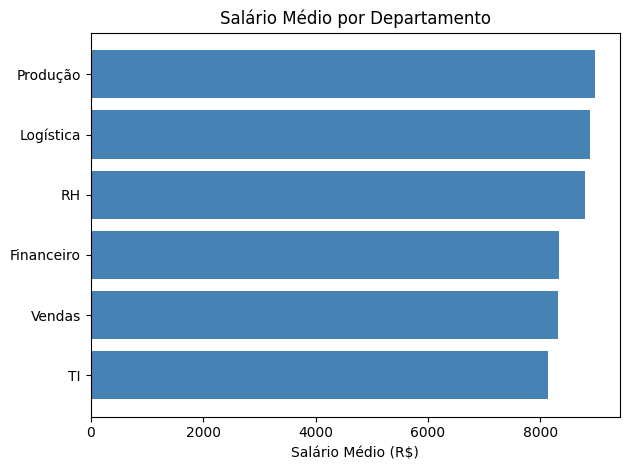

In [9]:
# Ordena do menor para o maior para que o gráfico horizontal seja legível
dados = resumo.sort_values("media")

plt.barh(dados["Departamento"], dados["media"], color="steelblue")
plt.title("Salário Médio por Departamento")
plt.xlabel("Salário Médio (R$)")
plt.tight_layout()
plt.show()


### O que este gráfico mostra?
- Cada barra mostra o salário médio de um departamento.
- Barras mais longas significam salários médios maiores.
### Como ler?
- A barra mais longa indica o departamento que paga mais.
- A barra mais curta indica o departamento que paga menos.
### Por que isso importa?
- Ajuda a comparar salários entre departamentos.
- Mostra onde pode ser necessário ajustar ou revisar os pagamentos.

### Exemplo 02 — groupby com duas colunas
Agrupe por duas colunas para obter visões cruzadas e use `unstack()` quando precisar de um formato de tabela para gráficos agrupados.


In [10]:
# Conta quantos funcionários existem em cada combinação Departamento + Status
headcount = (
    df.groupby(["Departamento", "Status"])["ID_Funcionario"]
    .count()
    .reset_index()
    .rename(columns={"ID_Funcionario": "Quantidade"})
)

print(headcount.to_string(index=False))

# Calcula o salário médio por departamento e gênero
sal_genero = (
    df.groupby(["Departamento", "Genero"])["Salario"]
    .mean()
    .round(2)
    .reset_index()
)

print("\nSalário médio por Depto e Gênero (5 primeiras):")
print(sal_genero.head(6).to_string(index=False))


Departamento  Status  Quantidade
  Financeiro   Ativo          96
  Financeiro Inativo          93
   Logística   Ativo          71
   Logística Inativo          85
    Produção   Ativo         100
    Produção Inativo          82
          RH   Ativo          92
          RH Inativo          74
          TI   Ativo          71
          TI Inativo          76
      Vendas   Ativo          85
      Vendas Inativo          75

Salário médio por Depto e Gênero (5 primeiras):
Departamento Genero  Salario
  Financeiro      F  8467.26
  Financeiro      M  8208.56
   Logística      F  8843.49
   Logística      M  8944.41
    Produção      F  8797.64
    Produção      M  9118.66


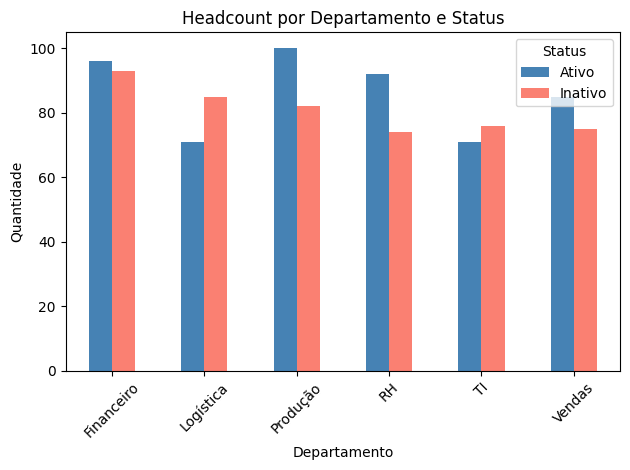

In [11]:
# Reusa o groupby anterior e transforma o segundo nível do índice em colunas
hc_pivot = (
    df.groupby(["Departamento", "Status"])["ID_Funcionario"]
    .count()
    .unstack(fill_value=0)
)

# Cada coluna criada por unstack vira uma série no gráfico de barras agrupadas
hc_pivot.plot(kind="bar", color=["steelblue", "salmon"])
plt.title("Headcount por Departamento e Status")
plt.xlabel("Departamento")
plt.ylabel("Quantidade")
plt.xticks(rotation=45)
plt.legend(title="Status")
plt.tight_layout()
plt.show()


### O que este gráfico mostra?
- Cada grupo de barras mostra um departamento.
- Cada cor representa um status diferente, por exemplo ativo ou inativo.
### Como ler?
- Compare as barras de cores diferentes dentro do mesmo departamento.
- Uma barra maior mostra mais pessoas naquele status.
### Por que isso importa?
- Ajuda a ver quantas pessoas existem em cada departamento.
- Mostra se um departamento tem muitos funcionários inativos ou poucos ativos.

### Exemplo 03 — groupby temporal com gráfico de linha
Quando o agrupamento envolve tempo, o gráfico de linha mostra tendência melhor que barras.


In [12]:
# Extrai o ano da data de admissão para poder agrupar por ano
df["Ano_Admissao"] = df["Data_Admissao"].dt.year

# Conta quantos funcionários foram admitidos em cada ano
admissoes_ano = (
    df.groupby("Ano_Admissao")["ID_Funcionario"]
    .count()
    .reset_index()
    .rename(columns={"ID_Funcionario": "Admissoes"})
    .sort_values("Ano_Admissao")
)

print(admissoes_ano.to_string(index=False))


 Ano_Admissao  Admissoes
         2015         33
         2016         87
         2017         99
         2018         89
         2019        101
         2020         94
         2021         94
         2022        108
         2023        106
         2024        113
         2025         76


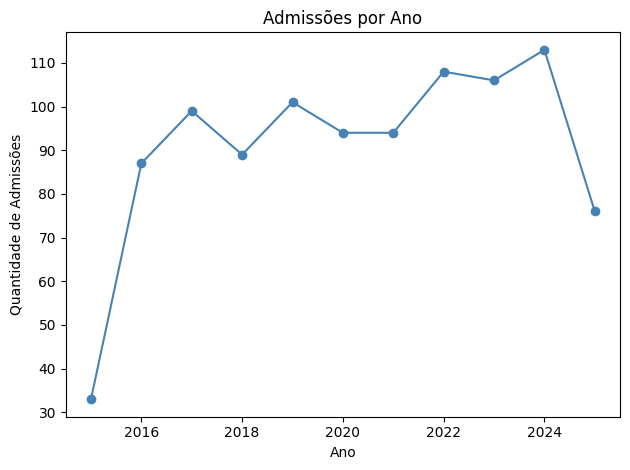

In [13]:
# Usa um gráfico de linha para mostrar a tendência de admissões
plt.plot(
    admissoes_ano["Ano_Admissao"],
    admissoes_ano["Admissoes"],
    marker="o",
    color="steelblue"
)
plt.title("Admissões por Ano")
plt.xlabel("Ano")
plt.ylabel("Quantidade de Admissões")
plt.tight_layout()
plt.show()


### O que este gráfico mostra?
- Cada ponto mostra quantos funcionários foram admitidos em um ano.
- A linha mostra se as admissões aumentam ou diminuem ao longo do tempo.
### Como ler?
- Se a linha sobe, a empresa contratou mais nesse ano.
- Se a linha desce, a empresa contratou menos nesse ano.
### Por que isso importa?
- Ajuda a ver se a empresa está crescendo ou reduzindo contratações.
- Mostra tendências de necessidade de novos funcionários.

## Bloco 2 — merge e pivot_table
`merge` é o JOIN do SQL e `pivot_table` é como criar uma tabela dinâmica em uma linha.


### Exemplo 04 — criando uma tabela de metas e cruzando com o resumo salarial
Use `pd.merge()` para comparar o salário médio real com metas salariais por departamento.


In [14]:
# Cria manualmente a tabela de metas de salário por departamento
metas = pd.DataFrame({
    "Departamento": [
        "Produção", "RH", "Financeiro",
        "Logística", "TI", "Vendas"
    ],
    "Meta_Salario": [9000, 8500, 8200, 8000, 8800, 8000]
})

print("Tabela de metas:")
print(metas.to_string(index=False))


Tabela de metas:
Departamento  Meta_Salario
    Produção          9000
          RH          8500
  Financeiro          8200
   Logística          8000
          TI          8800
      Vendas          8000


In [15]:
# Cruza o resumo salarial com a tabela de metas
comparacao = pd.merge(
    resumo[["Departamento", "media"]],
    metas,
    on="Departamento",
    how="inner"
)

# Calcula a diferença entre o salário médio real e a meta
comparacao["Diferenca"] = (comparacao["media"] - comparacao["Meta_Salario"]).round(2)
comparacao["Status_Meta"] = comparacao["Diferenca"].apply(
    lambda x: "✅ Acima" if x >= 0 else "❌ Abaixo"
)

print(comparacao.to_string(index=False))


Departamento   media  Meta_Salario  Diferenca Status_Meta
    Produção 8968.73          9000     -31.27    ❌ Abaixo
   Logística 8881.66          8000     881.66     ✅ Acima
          RH 8791.58          8500     291.58     ✅ Acima
  Financeiro 8333.12          8200     133.12     ✅ Acima
      Vendas 8317.08          8000     317.08     ✅ Acima
          TI 8142.91          8800    -657.09    ❌ Abaixo


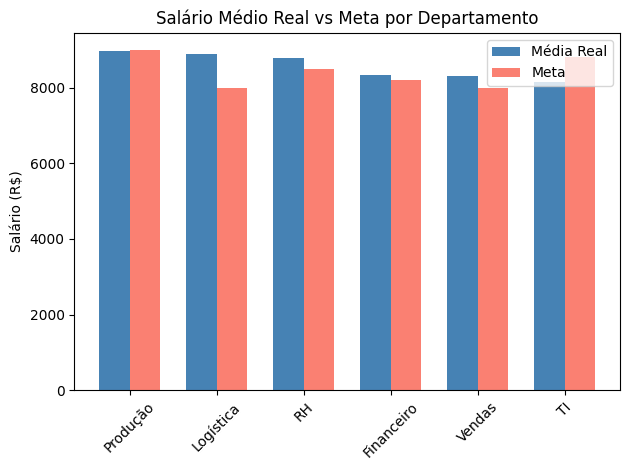

In [16]:
# Usa numpy para posicionar duas barras lado a lado
x = np.arange(len(comparacao))
largura = 0.35

plt.bar(x - largura / 2, comparacao["media"], largura, label="Média Real", color="steelblue")
plt.bar(x + largura / 2, comparacao["Meta_Salario"], largura, label="Meta", color="salmon")
plt.xticks(x, comparacao["Departamento"], rotation=45)
plt.title("Salário Médio Real vs Meta por Departamento")
plt.ylabel("Salário (R$)")
plt.legend()
plt.tight_layout()
plt.show()


### O que este gráfico mostra?
- Cada departamento tem duas barras: uma para o salário médio real e outra para a meta.
- A barra azul mostra o salário médio real e a barra vermelha mostra a meta salarial.
### Como ler?
- Compare as duas barras do mesmo departamento.
- Se a barra real for menor que a meta, o departamento está abaixo do objetivo.
### Por que isso importa?
- Mostra quais departamentos precisam aumentar o salário médio.
- Ajuda a ver onde a meta ainda não foi atingida.

### Exemplo 05 — `pivot_table` para relatório cruzado
`pivot_table` cria uma tabela bidimensional com valores agregados em uma linha de código.


In [17]:
# Cria uma tabela cruzada de salário médio por departamento e cargo
pivot = pd.pivot_table(
    df,
    values="Salario",
    index="Departamento",
    columns="Cargo",
    aggfunc="mean",
    fill_value=0,
).round(0)

print(pivot.to_string())


Cargo         Analista  Assistente  Coordenador  Gerente  Técnico
Departamento                                                     
Financeiro      8022.0      8636.0       8386.0   8129.0   8606.0
Logística       8248.0      9210.0       9252.0   8554.0   9028.0
Produção        9621.0      9937.0       7533.0   9308.0   8658.0
RH              8440.0      8288.0       9826.0   9167.0   7673.0
TI              8556.0      8655.0       8439.0   6959.0   8231.0
Vendas          9071.0      8050.0       8948.0   7935.0   7646.0


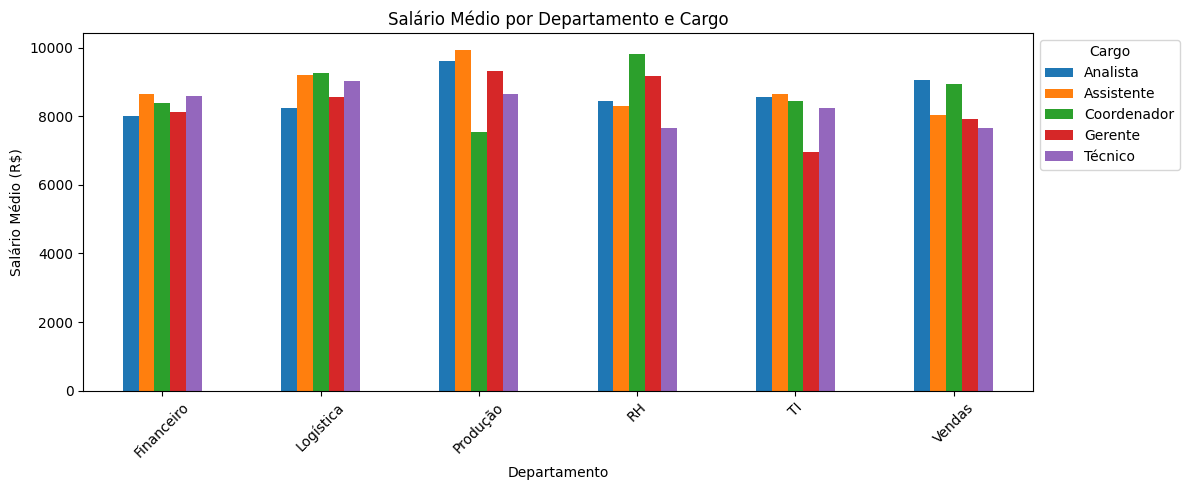

In [18]:
# Plota o resultado do pivot_table em barras agrupadas
pivot.plot(kind="bar", figsize=(12, 5))
plt.title("Salário Médio por Departamento e Cargo")
plt.xlabel("Departamento")
plt.ylabel("Salário Médio (R$)")
plt.xticks(rotation=45)
plt.legend(title="Cargo", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()


### O que este gráfico mostra?
- Cada grupo de barras mostra um departamento.
- Cada cor representa um cargo diferente dentro desse departamento.
### Como ler?
- Compare as barras do mesmo departamento para ver quais cargos pagam mais.
- Compare o mesmo cargo entre departamentos para ver diferenças de salário.
### Por que isso importa?
- Mostra quais cargos têm salários maiores ou menores.
- Ajuda a entender diferenças salariais dentro de cada departamento.

## Exercício prático — Dia 02
Complete os passos no notebook usando a base `base_rh.xlsx` e crie os gráficos finais pedindo ao gerente de produção.

1. Carregue `base_rh.xlsx` com `pd.read_excel(URL)` e converta `Data_Admissao` para datetime. Crie `Ano_Admissao` com `.dt.year`.
2. Use `groupby(["Departamento", "Cargo"])` para contar funcionários e exiba o resultado.
3. Use `groupby("Ano_Admissao")` para contar admissões por ano e filtre 2020–2024 com `query()`.
4. Crie uma tabela de metas de headcount por departamento com `pd.DataFrame` e faça `merge left` com o total por departamento. Identifique se a meta foi atingida.
5. Crie um `pivot_table` de `Salario` médio por `Departamento` e `Genero`. Calcule a diferença `F - M`.
6. Plote admissões por ano com `plt.plot(..., marker="o")`.
7. Plote o `pivot_table` de salário médio por gênero com `pivot.plot(kind="bar")`.
8. Faça commit com mensagem `semana 05 - dia 02: groupby, merge, pivot_table, graficos`.


## Gabarito resumido
- Para filtrar anos: `query("Ano_Admissao >= 2020 and Ano_Admissao <= 2024")`.
- Para calcular diferença salarial por gênero: crie `pivot_genero` e depois `pivot_genero["Diferenca_F_M"] = (pivot_genero["F"] - pivot_genero["M"]).round(2)`.
- Use `bbox_to_anchor=(1, 1)` se a legenda cobrir o gráfico.


## Observações finais
Hoje você aprendeu: `groupby` com múltiplas funções, `reset_index()` após groupby, `unstack()` para barras agrupadas, `merge` para cruzar tabelas e `pivot_table` para relatório cruzado.
